In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Entorno de análisis listo")

Entorno de análisis listo


In [2]:
# Ruta de los datos procesados
clean_path = Path("data/clean")

# Cargar dataset completo clasificado
df = pd.read_csv(
    clean_path / "online_retail_clean.csv",
    parse_dates=["InvoiceDate"],
    low_memory=False
)

# Cargar únicamente las ventas válidas
sales = pd.read_csv(
    clean_path / "online_retail_valid_sales.csv",
    parse_dates=["InvoiceDate"],
    low_memory=False
)

print("Datos cargados correctamente")
print("Dataset CLEAN:", df.shape)
print("Ventas válidas:", sales.shape)

sales.head()

Datos cargados correctamente
Dataset CLEAN: (536641, 19)
Ventas válidas: (524878, 19)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,IsNegativeQuantity,IsZeroPrice,IsNegativePrice,ValidSale,GrossLineValue,Year,Month,YearMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,False,False,False,False,True,15.30,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,False,False,False,True,20.34,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,False,False,False,False,True,22.00,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,False,False,False,True,20.34,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,False,False,False,True,20.34,2010,12,2010-12,Wednesday,8


In [3]:
# Estandarizar identificadores como texto
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
sales["InvoiceNo"] = sales["InvoiceNo"].astype(str)

df["StockCode"] = df["StockCode"].astype(str)
sales["StockCode"] = sales["StockCode"].astype(str)

# KPIs principales
total_revenue = sales["GrossLineValue"].sum()
total_orders = sales["InvoiceNo"].nunique()
total_customers = sales["CustomerID"].nunique()
total_units = sales["Quantity"].sum()

average_order_value = total_revenue / total_orders
revenue_per_customer = total_revenue / total_customers

kpis = pd.DataFrame({
    "KPI": [
        "Ingresos brutos",
        "Pedidos",
        "Clientes identificados",
        "Unidades vendidas",
        "Ticket promedio",
        "Ingreso promedio por cliente"
    ],
    "Valor": [
        total_revenue,
        total_orders,
        total_customers,
        total_units,
        average_order_value,
        revenue_per_customer
    ]
})

kpis

,KPI,Valor
0,Ingresos brutos,"10,642,110.80"
1,Pedidos,"19,960.00"
2,Clientes identificados,"4,338.00"
3,Unidades vendidas,"5,572,420.00"
4,Ticket promedio,533.17
5,Ingreso promedio por cliente,"2,453.23"


In [4]:
# Crear variable mensual
sales["Month"] = sales["InvoiceDate"].dt.to_period("M")

# Ingresos por mes
monthly_revenue = (
    sales.groupby("Month")["GrossLineValue"]
    .sum()
    .reset_index()
)

# Convertir periodo a fecha para graficar
monthly_revenue["Month"] = monthly_revenue["Month"].dt.to_timestamp()

monthly_revenue

,Month,GrossLineValue
0,2010-12-01,"821,452.73"
1,2011-01-01,"689,811.61"
2,2011-02-01,"522,545.56"
3,2011-03-01,"716,215.26"
4,2011-04-01,"536,968.49"
5,2011-05-01,"769,296.61"
6,2011-06-01,"760,547.01"
7,2011-07-01,"718,076.12"
8,2011-08-01,"757,841.38"
9,2011-09-01,"1,056,435.19"


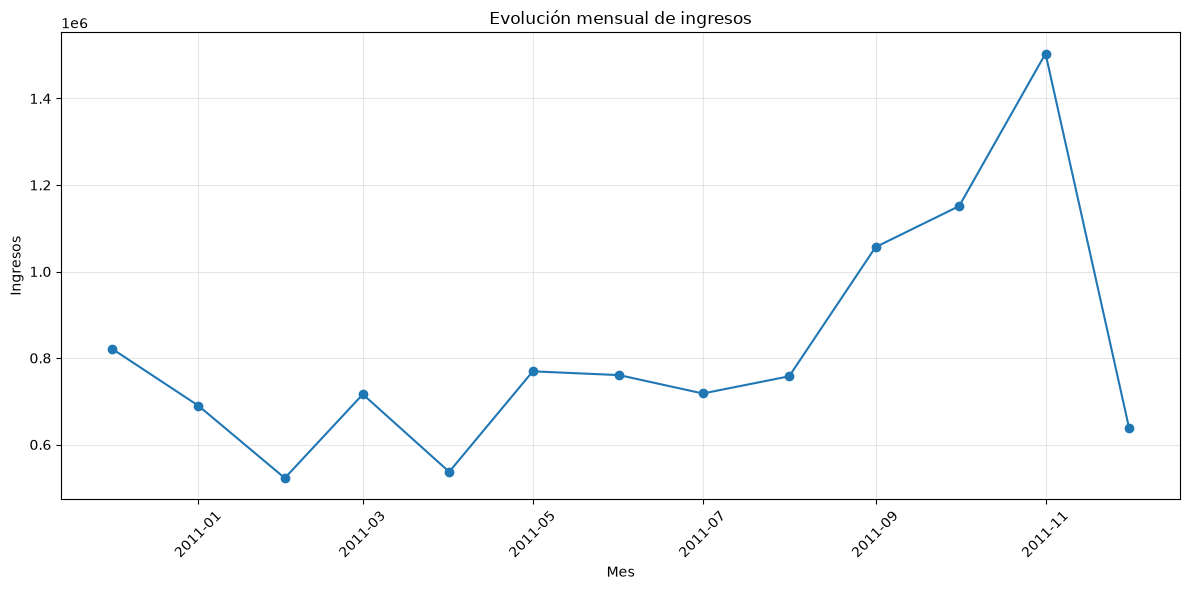

In [5]:
# Evolución mensual de ingresos

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["GrossLineValue"],
    marker="o"
)

plt.title("Evolución mensual de ingresos")
plt.xlabel("Mes")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Verificar cobertura temporal del dataset

print("Primera fecha:", sales["InvoiceDate"].min())
print("Última fecha:", sales["InvoiceDate"].max())

print("\nÚltimas fechas registradas:")
print(
    sales["InvoiceDate"]
    .dt.date
    .value_counts()
    .sort_index()
    .tail(15)
)

Primera fecha: 2010-12-01 08:26:00
Última fecha: 2011-12-09 12:50:00

Últimas fechas registradas:
InvoiceDate
2011-11-23    3498
2011-11-24    3649
2011-11-25    3035
2011-11-27    2418
2011-11-28    3249
2011-11-29    4217
2011-11-30    3341
2011-12-01    2793
2011-12-02    2786
2011-12-04    1975
2011-12-05    5258
2011-12-06    3211
2011-12-07    2358
2011-12-08    4834
2011-12-09    1618
Name: count, dtype: int64


In [7]:
# Excluir meses parciales para análisis comparable
monthly_complete = monthly_revenue[
    (monthly_revenue["Month"] >= "2011-01-01") &
    (monthly_revenue["Month"] <= "2011-11-01")
].copy()

# Calcular crecimiento mensual
monthly_complete["Growth_MoM_%"] = (
    monthly_complete["GrossLineValue"]
    .pct_change() * 100
)

monthly_complete

,Month,GrossLineValue,Growth_MoM_%
1,2011-01-01,"689,811.61",NaN
2,2011-02-01,"522,545.56",-24.25
3,2011-03-01,"716,215.26",37.06
4,2011-04-01,"536,968.49",-25.03
5,2011-05-01,"769,296.61",43.27
6,2011-06-01,"760,547.01",-1.14
7,2011-07-01,"718,076.12",-5.58
8,2011-08-01,"757,841.38",5.54
9,2011-09-01,"1,056,435.19",39.40
10,2011-10-01,"1,151,263.73",8.98


In [8]:
# Análisis mensual: ingresos, pedidos, unidades y ticket promedio

monthly_business = (
    sales[
        (sales["InvoiceDate"] >= "2011-01-01") &
        (sales["InvoiceDate"] < "2011-12-01")
    ]
    .groupby(sales["InvoiceDate"].dt.to_period("M"))
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

# Ticket promedio por pedido
monthly_business["Avg_Order_Value"] = (
    monthly_business["Revenue"] / monthly_business["Orders"]
)

monthly_business

,InvoiceDate,Revenue,Orders,Units,Avg_Order_Value
0,2011-01,"689,811.61",1086,387099,635.19
1,2011-02,"522,545.56",1100,282934,475.04
2,2011-03,"716,215.26",1454,376599,492.58
3,2011-04,"536,968.49",1246,307953,430.95
4,2011-05,"769,296.61",1681,395001,457.64
5,2011-06,"760,547.01",1533,388511,496.12
6,2011-07,"718,076.12",1475,399693,486.83
7,2011-08,"757,841.38",1361,421020,556.83
8,2011-09,"1,056,435.19",1837,569573,575.09
9,2011-10,"1,151,263.73",2040,621029,564.34


In [9]:
# Rendimiento por país

country_performance = (
    sales.groupby("Country")
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
    .reset_index()
)

# Participación sobre los ingresos totales
country_performance["Revenue_Share_%"] = (
    country_performance["Revenue"] /
    country_performance["Revenue"].sum() * 100
)

country_performance.head(10)

,Country,Revenue,Orders,Units,Customers,Revenue_Share_%
0,United Kingdom,"9,001,744.09",18019,4646906,3920,84.59
1,Netherlands,"285,446.34",94,200361,9,2.68
2,EIRE,"283,140.52",288,147007,3,2.66
3,Germany,"228,678.40",457,119154,94,2.15
4,France,"209,625.37",392,112060,87,1.97
5,Australia,"138,453.81",57,83891,9,1.30
6,Spain,"61,558.56",90,27933,30,0.58
7,Switzerland,"57,067.60",54,30617,21,0.54
8,Belgium,"41,196.34",98,23237,25,0.39
9,Sweden,"38,367.83",36,36078,8,0.36


In [10]:
# Crear segmento geográfico
sales["Market"] = np.where(
    sales["Country"] == "United Kingdom",
    "United Kingdom",
    "International"
)

# Analizar ingresos mensuales por mercado
market_monthly = (
    sales[
        (sales["InvoiceDate"] >= "2011-01-01") &
        (sales["InvoiceDate"] < "2011-12-01")
    ]
    .groupby([
        sales["InvoiceDate"].dt.to_period("M"),
        "Market"
    ])
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

market_monthly

,InvoiceDate,Market,Revenue,Orders
0,2011-01,International,"129,835.78",115
1,2011-01,United Kingdom,"559,975.83",971
2,2011-02,International,"93,558.94",105
3,2011-02,United Kingdom,"428,986.62",995
4,2011-03,International,"131,404.48",146
5,2011-03,United Kingdom,"584,810.78",1308
6,2011-04,International,"61,290.86",93
7,2011-04,United Kingdom,"475,677.63",1153
8,2011-05,International,"131,191.72",158
9,2011-05,United Kingdom,"638,104.89",1523


In [11]:
# Analizar desempeño por producto
product_performance = (
    sales.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Units=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

# Participación sobre ingresos totales
product_performance["Revenue_Share_%"] = (
    product_performance["Revenue"] /
    product_performance["Revenue"].sum() * 100
)

product_performance.head(15)

,StockCode,Description,Revenue,Units,Orders,Customers,Revenue_Share_%
4150,DOT,DOTCOM POSTAGE,"206,248.77",706,706,1,1.94
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,881,1.64
2668,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,1.58
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189,856,0.98
2877,47566,PARTY BUNTING,"99,445.23",18283,1685,708,0.93
3619,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,635,0.88
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138,0.77
4153,POST,POSTAGE,"78,101.88",3150,1126,331,0.73
4151,M,Manual,"77,750.27",6984,289,197,0.73
2029,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,450,0.63


In [12]:
# Excluir códigos que no representan productos comerciales
non_product_codes = ["DOT", "POST", "M"]

products = sales[
    ~sales["StockCode"].astype(str).isin(non_product_codes)
].copy()

product_performance_clean = (
    products.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Units=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

product_performance_clean["Revenue_Share_%"] = (
    product_performance_clean["Revenue"]
    / product_performance_clean["Revenue"].sum()
    * 100
)

product_performance_clean.head(15)

,StockCode,Description,Revenue,Units,Orders,Customers,Revenue_Share_%
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,881,1.69
2668,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,1.64
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189,856,1.01
2877,47566,PARTY BUNTING,"99,445.23",18283,1685,708,0.97
3619,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,635,0.92
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138,0.79
2029,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,450,0.65
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,1160,613,0.63
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1455,678,0.57
3059,79321,CHILLI LIGHTS,"54,096.36",10302,661,205,0.53


In [13]:
# Investigar productos con ingresos altos pero muy pocos pedidos/clientes
outlier_products = product_performance_clean[
    (product_performance_clean["Revenue"] >= 30000) &
    (product_performance_clean["Orders"] <= 5)
].copy()

outlier_products[
    ["StockCode", "Description", "Revenue", "Units", "Orders", "Customers", "Revenue_Share_%"]
]

,StockCode,Description,Revenue,Units,Orders,Customers,Revenue_Share_%
2668,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,1.64
1415,22502,PICNIC BASKET WICKER 60 PIECES,"39,619.50",61,2,1,0.39


In [14]:
# Revisar transacciones originales de los productos atípicos
outlier_codes = outlier_products["StockCode"].astype(str).tolist()

outlier_transactions = sales[
    sales["StockCode"].astype(str).isin(outlier_codes)
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "GrossLineValue"
    ]
].sort_values(["StockCode", "InvoiceDate"])

outlier_transactions

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,GrossLineValue
240,536392,22502,PICNIC BASKET WICKER SMALL,4,2010-12-01 10:29:00,5.95,"13,705.00",United Kingdom,23.80
372,536401,22502,PICNIC BASKET WICKER SMALL,2,2010-12-01 11:21:00,5.95,"15,862.00",United Kingdom,11.90
3443,536635,22502,PICNIC BASKET WICKER SMALL,8,2010-12-02 11:22:00,5.95,"15,955.00",United Kingdom,47.60
3551,536638,22502,PICNIC BASKET WICKER SMALL,4,2010-12-02 11:41:00,5.95,"16,244.00",United Kingdom,23.80
4765,536821,22502,PICNIC BASKET WICKER SMALL,3,2010-12-02 17:17:00,5.95,"17,757.00",United Kingdom,17.85
...,...,...,...,...,...,...,...,...,...
311458,565152,22502,PICNIC BASKET WICKER SMALL,2,2011-09-01 14:42:00,5.95,"17,799.00",United Kingdom,11.90
315164,565438,22502,PICNIC BASKET WICKER SMALL,2,2011-09-04 13:56:00,5.95,"17,229.00",United Kingdom,11.90
329570,566607,22502,PICNIC BASKET WICKER SMALL,2,2011-09-13 16:40:00,5.95,"13,032.00",United Kingdom,11.90
348335,568188,22502,PICNIC BASKET WICKER SMALL,1,2011-09-25 14:33:00,2.00,"16,049.00",United Kingdom,2.00


In [15]:
# Revisar cuántas descripciones diferentes tiene cada StockCode
description_check = (
    sales.groupby("StockCode")
    .agg(
        UniqueDescriptions=("Description", "nunique"),
        Descriptions=("Description", lambda x: sorted(x.dropna().unique().tolist()))
    )
    .reset_index()
)

# Mostrar específicamente los códigos que estamos investigando
description_check[
    description_check["StockCode"].astype(str).isin(["22502", "23843"])
]

,StockCode,UniqueDescriptions,Descriptions
1384,22502,2,"[PICNIC BASKET WICKER 60 PIECES, PICNIC BASKET..."
2465,23843,1,"[PAPER CRAFT , LITTLE BIRDIE]"


In [16]:
# StockCodes asociados con más de una descripción
inconsistent_codes = (
    description_check[
        description_check["UniqueDescriptions"] > 1
    ]
    .sort_values("UniqueDescriptions", ascending=False)
)

print("StockCodes totales:",
      description_check["StockCode"].nunique())

print("StockCodes con múltiples descripciones:",
      len(inconsistent_codes))

print(
    "Porcentaje con inconsistencia:",
    round(
        len(inconsistent_codes) /
        description_check["StockCode"].nunique() * 100,
        2
    ),
    "%"
)

inconsistent_codes.head(20)

StockCodes totales: 3922
StockCodes con múltiples descripciones: 220
Porcentaje con inconsistencia: 5.61 %


,StockCode,UniqueDescriptions,Descriptions
2089,23236,4,"[DOILEY BISCUIT TIN, DOILEY STORAGE TIN, STORA..."
2049,23196,4,"[LEAVES MAGNETIC SHOPPING LIST, RETO LEAVES M..."
2056,23203,3,"[JUMBO BAG DOILEY PATTERNS, JUMBO BAG VINTAGE ..."
2207,23370,3,"[SET 36 COLOUR PENCILS DOILEY, SET 36 COLOURIN..."
2203,23366,3,"[SET 12 COLOUR PENCILS DOILEY, SET 12 COLOURIN..."
2228,23396,3,"[BUTTERFLY CUSHION COVER, LA JARDIN BOTANIQUE ..."
2245,23413,3,"[DECORATIVE VINTAGE COFFEE BOX, DECROTIVEVINT..."
1980,23126,3,"[DOLLCRAFT GIRL AMELIE, DOLLCRAFT GIRL AMELIE ..."
1985,23131,3,"[MISELTOE HEART WREATH CREAM, MISELTOE HEART W..."
2364,23535,3,"[BICYCLE SAFTEY WALL ART, WALL ART BICYCLE SAF..."


In [17]:
# Crear descripción canónica por StockCode
canonical_description = (
    sales.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().index[0])
    .rename("CanonicalDescription")
    .reset_index()
)

canonical_description.head(10)

,StockCode,CanonicalDescription
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE
5,10124G,ARMY CAMO BOOKCOVER TAPE
6,10125,MINI FUNKY DESIGN TAPES
7,10133,COLOURING PENCILS BROWN TUBE
8,10135,COLOURING PENCILS BROWN TUBE
9,11001,ASSTD DESIGN RACING CAR PEN


In [18]:
# Rendimiento definitivo por producto
product_performance_final = (
    sales.groupby("StockCode")
    .agg(
        Revenue=("GrossLineValue", "sum"),
        Units=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

# Incorporar descripción canónica
product_performance_final = product_performance_final.merge(
    canonical_description,
    on="StockCode",
    how="left"
)

# Participación de cada producto en los ingresos
product_performance_final["Revenue_Share_%"] = (
    product_performance_final["Revenue"]
    / product_performance_final["Revenue"].sum()
    * 100
)

# Ordenar de mayor a menor ingreso
product_performance_final = (
    product_performance_final
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

product_performance_final.head(15)

,StockCode,Revenue,Units,Orders,Customers,CanonicalDescription,Revenue_Share_%
0,DOT,"206,248.77",706,706,1,DOTCOM POSTAGE,1.94
1,22423,"174,156.54",13851,1988,881,REGENCY CAKESTAND 3 TIER,1.64
2,23843,"168,469.60",80995,1,1,"PAPER CRAFT , LITTLE BIRDIE",1.58
3,85123A,"104,462.75",37641,2198,856,WHITE HANGING HEART T-LIGHT HOLDER,0.98
4,47566,"99,445.23",18283,1685,708,PARTY BUNTING,0.93
5,85099B,"94,159.81",48371,2089,635,JUMBO BAG RED RETROSPOT,0.88
6,23166,"81,700.92",78033,247,138,MEDIUM CERAMIC TOP STORAGE JAR,0.77
7,POST,"78,101.88",3150,1126,331,POSTAGE,0.73
8,M,"77,750.27",6984,289,197,Manual,0.73
9,23084,"66,870.03",30739,994,450,RABBIT NIGHT LIGHT,0.63


In [19]:
# Identificar códigos que no representan productos comerciales
non_product_codes = ["DOT", "POST", "M"]

# Crear clasificación analítica
product_performance_final["ProductType"] = np.where(
    product_performance_final["StockCode"].astype(str).isin(non_product_codes),
    "Non-product",
    "Product"
)

# Revisar registros clasificados como no-producto
product_performance_final[
    product_performance_final["ProductType"] == "Non-product"
][
    [
        "StockCode",
        "CanonicalDescription",
        "Revenue",
        "Units",
        "Orders",
        "Customers"
    ]
]

,StockCode,CanonicalDescription,Revenue,Units,Orders,Customers
0,DOT,DOTCOM POSTAGE,"206,248.77",706,706,1
7,POST,POSTAGE,"78,101.88",3150,1126,331
8,M,Manual,"77,750.27",6984,289,197


In [20]:
# Crear tabla exclusiva de productos comerciales
commercial_products = (
    product_performance_final[
        product_performance_final["ProductType"] == "Product"
    ]
    .copy()
    .sort_values("Revenue", ascending=False)
)

# Recalcular participación considerando únicamente productos
commercial_products["Product_Revenue_Share_%"] = (
    commercial_products["Revenue"]
    / commercial_products["Revenue"].sum()
    * 100
)

# Mostrar Top 15 productos comerciales
commercial_products[
    [
        "StockCode",
        "CanonicalDescription",
        "Revenue",
        "Units",
        "Orders",
        "Customers",
        "Product_Revenue_Share_%"
    ]
].head(15)

,StockCode,CanonicalDescription,Revenue,Units,Orders,Customers,Product_Revenue_Share_%
1,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,881,1.69
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,1.64
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.75",37641,2198,856,1.02
4,47566,PARTY BUNTING,"99,445.23",18283,1685,708,0.97
5,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,635,0.92
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138,0.79
9,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,450,0.65
10,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,1160,613,0.63
11,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1455,678,0.57
12,79321,CHILLI LIGHTS,"54,096.36",10302,661,205,0.53


In [21]:
# Analizar distribución del tamaño de los pedidos
order_size_analysis = (
    sales[
        ~sales["StockCode"].astype(str).isin(non_product_codes)
    ]
    .groupby("InvoiceNo")
    .agg(
        TotalUnits=("Quantity", "sum"),
        Revenue=("GrossLineValue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        CustomerID=("CustomerID", "first")
    )
    .reset_index()
)

# Estadísticas descriptivas
order_size_analysis[
    ["TotalUnits", "Revenue", "UniqueProducts"]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,TotalUnits,Revenue,UniqueProducts
count,"19,792.00","19,792.00","19,792.00"
mean,281.00,519.40,26.15
std,958.36,"1,767.37",47.01
min,1.00,0.38,1.00
50%,152.00,302.25,15.00
75%,297.00,482.40,29.00
90%,531.00,915.81,52.00
95%,810.00,"1,510.42",75.00
99%,"2,232.27","4,415.67",218.00
max,"80,995.00","168,469.60","1,109.00"


In [22]:
# Identificar los pedidos más extremos por número de unidades
extreme_orders = (
    order_size_analysis
    .sort_values("TotalUnits", ascending=False)
    .head(10)
)

extreme_orders

,InvoiceNo,TotalUnits,Revenue,UniqueProducts,CustomerID
19755,581483,80995,"168,469.60",1,"16,446.00"
2110,541431,74215,"77,183.60",1,"12,346.00"
8846,556917,15049,"22,775.93",138,"12,415.00"
11550,563076,14730,"19,150.66",119,"14,646.00"
16770,574941,14149,"52,940.94",101,NaN
17419,576365,13956,"50,653.91",99,NaN
15465,572035,13392,"20,277.92",125,"14,646.00"
13432,567423,12572,"31,698.16",12,"17,450.00"
7048,552883,12266,"14,415.74",92,"14,646.00"
11791,563614,12196,"21,880.44",97,"12,415.00"


In [23]:
# Auditar las dos transacciones de mayor volumen
audit_invoices = sales[
    sales["InvoiceNo"].astype(str).isin(["581483", "541431"])
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "GrossLineValue"
    ]
].sort_values(["InvoiceNo", "GrossLineValue"], ascending=[True, False])

audit_invoices

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,GrossLineValue
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00",United Kingdom,"77,183.60"
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom,"168,469.60"


In [24]:
# Analizar comportamiento histórico de los clientes
# asociados a las dos transacciones extremas

extreme_customers = [12346, 16446]

customer_history = (
    sales[
        sales["CustomerID"].isin(extreme_customers)
    ]
    .groupby("CustomerID")
    .agg(
        Orders=("InvoiceNo", "nunique"),
        TotalUnits=("Quantity", "sum"),
        TotalRevenue=("GrossLineValue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_history

,CustomerID,Orders,TotalUnits,TotalRevenue,UniqueProducts,FirstPurchase,LastPurchase
0,"12,346.00",1,74215,"77,183.60",1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,"16,446.00",2,80997,"168,472.50",3,2011-05-18 09:52:00,2011-12-09 09:15:00


In [25]:
# Identificar pedidos de volumen extraordinario
# Usamos el percentil 99 como referencia estadística

units_p99 = order_size_analysis["TotalUnits"].quantile(0.99)

print(f"Percentil 99 de unidades por pedido: {units_p99:,.0f}")

# Clasificar pedidos
order_size_analysis["OrderType"] = np.where(
    order_size_analysis["TotalUnits"] > units_p99,
    "Bulk / Extreme",
    "Regular"
)

order_size_analysis["OrderType"].value_counts()

Percentil 99 de unidades por pedido: 2,232


OrderType
Regular           19594
Bulk / Extreme      198
Name: count, dtype: int64

In [26]:
# Analizar impacto económico por tipo de pedido
order_type_impact = (
    order_size_analysis
    .groupby("OrderType")
    .agg(
        Orders=("InvoiceNo", "nunique"),
        TotalUnits=("TotalUnits", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

# Participación sobre el total
order_type_impact["Order_Share_%"] = (
    order_type_impact["Orders"] /
    order_type_impact["Orders"].sum() * 100
)

order_type_impact["Unit_Share_%"] = (
    order_type_impact["TotalUnits"] /
    order_type_impact["TotalUnits"].sum() * 100
)

order_type_impact["Revenue_Share_%"] = (
    order_type_impact["Revenue"] /
    order_type_impact["Revenue"].sum() * 100
)

order_type_impact.round(2)

,OrderType,Orders,TotalUnits,Revenue,Order_Share_%,Unit_Share_%,Revenue_Share_%
0,Bulk / Extreme,198,1020250,"1,624,285.93",1.00,18.34,15.80
1,Regular,19594,4541330,"8,655,723.95",99.00,81.66,84.20


In [27]:
# Analizar quién genera los pedidos Bulk / Extreme

bulk_invoice_numbers = order_size_analysis.loc[
    order_size_analysis["OrderType"] == "Bulk / Extreme",
    "InvoiceNo"
]

bulk_transactions = sales[
    sales["InvoiceNo"].isin(bulk_invoice_numbers)
].copy()

bulk_customers = (
    bulk_transactions
    .groupby("CustomerID")
    .agg(
        BulkOrders=("InvoiceNo", "nunique"),
        BulkUnits=("Quantity", "sum"),
        BulkRevenue=("GrossLineValue", "sum")
    )
    .reset_index()
    .sort_values("BulkRevenue", ascending=False)
)

print("Clientes identificados con pedidos Bulk / Extreme:")
print(bulk_customers["CustomerID"].nunique())

bulk_customers.head(15)

Clientes identificados con pedidos Bulk / Extreme:
60


,CustomerID,BulkOrders,BulkUnits,BulkRevenue
31,"14,646.00",26,170528,"238,009.29"
46,"16,446.00",1,80995,"168,469.60"
4,"12,415.00",10,75616,"120,379.96"
52,"17,450.00",8,41366,"112,011.76"
58,"18,102.00",8,25194,"88,582.03"
0,"12,346.00",1,74215,"77,183.60"
27,"14,156.00",8,33192,"66,343.98"
53,"17,511.00",15,46893,"61,781.21"
47,"16,684.00",10,43194,"56,173.94"
38,"15,749.00",2,16058,"36,696.80"


In [28]:
# Medir concentración del revenue dentro del segmento Bulk / Extreme

bulk_customers = bulk_customers.sort_values(
    "BulkRevenue",
    ascending=False
).reset_index(drop=True)

total_bulk_revenue = bulk_customers["BulkRevenue"].sum()

bulk_customers["Revenue_Share_%"] = (
    bulk_customers["BulkRevenue"] /
    total_bulk_revenue * 100
)

bulk_customers["Cumulative_Revenue_%"] = (
    bulk_customers["Revenue_Share_%"].cumsum()
)

print(f"Revenue total Bulk / Extreme: {total_bulk_revenue:,.2f}")
print(f"Clientes Bulk identificados: {len(bulk_customers)}")
print(
    f"Top 5 clientes: "
    f"{bulk_customers.head(5)['BulkRevenue'].sum() / total_bulk_revenue * 100:.2f}%"
)
print(
    f"Top 10 clientes: "
    f"{bulk_customers.head(10)['BulkRevenue'].sum() / total_bulk_revenue * 100:.2f}%"
)

bulk_customers.head(15)

Revenue total Bulk / Extreme: 1,433,663.90
Clientes Bulk identificados: 60
Top 5 clientes: 50.74%
Top 10 clientes: 71.54%


,CustomerID,BulkOrders,BulkUnits,BulkRevenue,Revenue_Share_%,Cumulative_Revenue_%
0,"14,646.00",26,170528,"238,009.29",16.60,16.60
1,"16,446.00",1,80995,"168,469.60",11.75,28.35
2,"12,415.00",10,75616,"120,379.96",8.40,36.75
3,"17,450.00",8,41366,"112,011.76",7.81,44.56
4,"18,102.00",8,25194,"88,582.03",6.18,50.74
5,"12,346.00",1,74215,"77,183.60",5.38,56.12
6,"14,156.00",8,33192,"66,343.98",4.63,60.75
7,"17,511.00",15,46893,"61,781.21",4.31,65.06
8,"16,684.00",10,43194,"56,173.94",3.92,68.98
9,"15,749.00",2,16058,"36,696.80",2.56,71.54


## Hallazgo: pedidos de alto volumen y concentración de ingresos

Se definieron como **Bulk / Extreme** los pedidos cuyo volumen supera el percentil 99 de unidades por pedido (> 2,232 unidades).

Los resultados muestran que:

- Solo el **1.0% de los pedidos (198)** pertenece a esta categoría.
- Estos pedidos representan el **18.34% de las unidades vendidas**.
- Generan el **15.80% del revenue analizado**.
- Se identificaron **60 clientes** asociados a pedidos de alto volumen.
- Los **5 principales clientes concentran el 50.74%** del revenue de este segmento.
- Los **10 principales concentran el 71.54%**.
- El principal cliente representa individualmente el **16.60%** del revenue Bulk / Extreme.

### Interpretación de negocio

Los pedidos de alto volumen constituyen una proporción pequeña de las transacciones, pero tienen un impacto económico desproporcionado. Además, el revenue de este segmento presenta una concentración considerable en un grupo reducido de clientes.

Esto sugiere la existencia de un comportamiento de compra diferenciado que podría justificar una estrategia específica de retención, seguimiento y segmentación para clientes de alto volumen.

Sin embargo, la clasificación **Bulk / Extreme es estadística y no comercial**; con la información disponible no puede afirmarse que estos clientes sean mayoristas.

### Implicación analítica

Los pedidos extremos se conservarán en el dataset porque representan transacciones observadas y aportan información relevante sobre el negocio. No obstante, deberán considerarse por separado cuando puedan distorsionar métricas descriptivas del comportamiento típico de compra.

## 6. Customer Analysis

En esta sección se analiza el comportamiento de los clientes identificados para comprender su frecuencia de compra, volumen de pedidos y contribución a los ingresos.

El objetivo es identificar diferencias entre clientes ocasionales, recurrentes y de alto valor, así como evaluar la concentración del revenue en la base de clientes.

In [29]:
# Construir tabla de comportamiento por cliente
customer_analysis = (
    sales
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Orders=("InvoiceNo", "nunique"),
        TotalUnits=("Quantity", "sum"),
        Revenue=("GrossLineValue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

# Métricas adicionales
customer_analysis["Avg_Order_Value"] = (
    customer_analysis["Revenue"] /
    customer_analysis["Orders"]
)

customer_analysis["Active_Days"] = (
    customer_analysis["LastPurchase"] -
    customer_analysis["FirstPurchase"]
).dt.days

print(f"Clientes analizados: {len(customer_analysis):,}")

customer_analysis.head()

Clientes analizados: 4,338


,CustomerID,Orders,TotalUnits,Revenue,UniqueProducts,FirstPurchase,LastPurchase,Avg_Order_Value,Active_Days
0,"12,346.00",1,74215,"77,183.60",1,2011-01-18 10:01:00,2011-01-18 10:01:00,"77,183.60",0
1,"12,347.00",7,2458,"4,310.00",103,2010-12-07 14:57:00,2011-12-07 15:52:00,615.71,365
2,"12,348.00",4,2341,"1,797.24",22,2010-12-16 19:09:00,2011-09-25 13:13:00,449.31,282
3,"12,349.00",1,631,"1,757.55",73,2011-11-21 09:51:00,2011-11-21 09:51:00,"1,757.55",0
4,"12,350.00",1,197,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40,0


In [30]:
# Estadísticas descriptivas del comportamiento de clientes
customer_stats = customer_analysis[
    [
        "Orders",
        "TotalUnits",
        "Revenue",
        "UniqueProducts",
        "Avg_Order_Value",
        "Active_Days"
    ]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

customer_stats.round(2)

,Orders,TotalUnits,Revenue,UniqueProducts,Avg_Order_Value,Active_Days
count,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,4.27,"1,187.64","2,048.69",61.50,417.65,130.45
std,7.70,"5,043.62","8,985.23",85.37,"1,796.51",132.04
min,1.00,1.00,3.75,1.00,3.45,0.00
50%,2.00,378.00,668.57,35.00,291.94,92.50
75%,5.00,989.75,"1,660.60",77.00,428.28,251.75
90%,9.00,"2,110.60","3,640.84",143.00,659.74,339.00
95%,13.00,"3,570.90","5,790.00",205.00,936.33,356.00
99%,30.00,"11,016.24","19,780.49",354.00,"2,031.16",367.00
max,209.00,"196,915.00","280,206.02","1,787.00","84,236.25",373.00


In [31]:
# Clasificar clientes según recurrencia de compra
customer_analysis["CustomerType"] = np.where(
    customer_analysis["Orders"] == 1,
    "One-time",
    "Repeat"
)

# Distribución de clientes
customer_recurrence = (
    customer_analysis["CustomerType"]
    .value_counts()
    .rename_axis("CustomerType")
    .reset_index(name="Customers")
)

customer_recurrence["Customer_Share_%"] = (
    customer_recurrence["Customers"]
    / customer_recurrence["Customers"].sum()
    * 100
)

customer_recurrence.round(2)

,CustomerType,Customers,Customer_Share_%
0,Repeat,2845,65.58
1,One-time,1493,34.42


In [32]:
# Impacto económico por tipo de cliente
customer_type_impact = (
    customer_analysis
    .groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "nunique"),
        Orders=("Orders", "sum"),
        TotalUnits=("TotalUnits", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

# Participación sobre el revenue total
customer_type_impact["Revenue_Share_%"] = (
    customer_type_impact["Revenue"]
    / customer_type_impact["Revenue"].sum()
    * 100
)

# Revenue promedio por cliente
customer_type_impact["Avg_Revenue_Per_Customer"] = (
    customer_type_impact["Revenue"]
    / customer_type_impact["Customers"]
)

customer_type_impact.round(2)

,CustomerType,Customers,Orders,TotalUnits,Revenue,Revenue_Share_%,Avg_Revenue_Per_Customer
0,One-time,1493,1493,403544,"613,989.56",6.91,411.25
1,Repeat,2845,17039,4748458,"8,273,219.33",93.09,"2,907.99"


In [33]:
# Ranking de clientes por revenue
customer_value_ranking = (
    customer_analysis
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

# Participación individual y acumulada
customer_value_ranking["Revenue_Share_%"] = (
    customer_value_ranking["Revenue"]
    / customer_value_ranking["Revenue"].sum()
    * 100
)

customer_value_ranking["Cumulative_Revenue_%"] = (
    customer_value_ranking["Revenue_Share_%"].cumsum()
)

# Mostrar los 15 clientes con mayor revenue
customer_value_ranking[
    [
        "CustomerID",
        "Orders",
        "TotalUnits",
        "Revenue",
        "Avg_Order_Value",
        "Revenue_Share_%",
        "Cumulative_Revenue_%"
    ]
].head(15).round(2)

,CustomerID,Orders,TotalUnits,Revenue,Avg_Order_Value,Revenue_Share_%,Cumulative_Revenue_%
0,"14,646.00",73,196915,"280,206.02","3,838.44",3.15,3.15
1,"18,102.00",60,64124,"259,657.30","4,327.62",2.92,6.07
2,"17,450.00",46,69973,"194,390.79","4,225.89",2.19,8.26
3,"16,446.00",2,80997,"168,472.50","84,236.25",1.90,10.16
4,"14,911.00",201,80240,"143,711.17",714.98,1.62,11.77
5,"12,415.00",21,77374,"124,914.53","5,948.31",1.41,13.18
6,"14,156.00",55,57768,"117,210.08","2,131.09",1.32,14.50
7,"17,511.00",31,64549,"91,062.38","2,937.50",1.02,15.52
8,"16,029.00",63,40108,"80,850.84","1,283.35",0.91,16.43
9,"12,346.00",1,74215,"77,183.60","77,183.60",0.87,17.30


In [34]:
# Analizar concentración del revenue por percentiles de clientes
import math

total_customers = len(customer_value_ranking)
total_revenue = customer_value_ranking["Revenue"].sum()

concentration_levels = [0.01, 0.05, 0.10, 0.20]

concentration_results = []

for level in concentration_levels:
    n_customers = math.ceil(total_customers * level)

    segment_revenue = (
        customer_value_ranking
        .head(n_customers)["Revenue"]
        .sum()
    )

    concentration_results.append({
        "Top_Customers_%": level * 100,
        "Customers": n_customers,
        "Revenue": segment_revenue,
        "Revenue_Share_%": segment_revenue / total_revenue * 100
    })

concentration_analysis = pd.DataFrame(concentration_results)

concentration_analysis.round(2)

,Top_Customers_%,Customers,Revenue,Revenue_Share_%
0,1.00,44,"2,849,468.17",32.06
1,5.00,217,"4,484,050.62",50.46
2,10.00,434,"5,461,374.89",61.45
3,20.00,868,"6,637,300.82",74.68


In [35]:
# Calcular cuántos clientes generan el 80% del revenue

customers_to_80 = (
    customer_value_ranking["Cumulative_Revenue_%"]
    .searchsorted(80)
    + 1
)

customer_share_to_80 = (
    customers_to_80 / len(customer_value_ranking) * 100
)

revenue_at_threshold = customer_value_ranking.loc[
    customers_to_80 - 1,
    "Cumulative_Revenue_%"
]

print(f"Clientes necesarios para alcanzar el 80% del revenue: {customers_to_80:,}")
print(f"Porcentaje de la base de clientes: {customer_share_to_80:.2f}%")
print(f"Revenue acumulado alcanzado: {revenue_at_threshold:.2f}%")

Clientes necesarios para alcanzar el 80% del revenue: 1,130
Porcentaje de la base de clientes: 26.05%
Revenue acumulado alcanzado: 80.01%


In [36]:
# Preparar fecha de referencia para análisis RFM

max_transaction_date = sales["InvoiceDate"].max()
min_transaction_date = sales["InvoiceDate"].min()

# Usamos un día después de la última transacción
# para que la recencia mínima sea 1 día
snapshot_date = max_transaction_date + pd.Timedelta(days=1)

print(f"Primera transacción: {min_transaction_date}")
print(f"Última transacción: {max_transaction_date}")
print(f"Fecha de referencia RFM: {snapshot_date}")

Primera transacción: 2010-12-01 08:26:00
Última transacción: 2011-12-09 12:50:00
Fecha de referencia RFM: 2011-12-10 12:50:00


In [37]:
# Construir tabla RFM por cliente

rfm = (
    sales
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (snapshot_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("GrossLineValue", "sum")
    )
    .reset_index()
)

print(f"Clientes en RFM: {len(rfm):,}")

rfm.head(10).round(2)

Clientes en RFM: 4,338


,CustomerID,Recency,Frequency,Monetary
0,"12,346.00",326,1,"77,183.60"
1,"12,347.00",2,7,"4,310.00"
2,"12,348.00",75,4,"1,797.24"
3,"12,349.00",19,1,"1,757.55"
4,"12,350.00",310,1,334.40
5,"12,352.00",36,8,"2,506.04"
6,"12,353.00",204,1,89.00
7,"12,354.00",232,1,"1,079.40"
8,"12,355.00",214,1,459.40
9,"12,356.00",23,3,"2,811.43"


In [38]:
# Analizar distribución de las métricas RFM

rfm_stats = (
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

rfm_stats.round(2)

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
90%,263.00,9.00,"3,640.84"
95%,312.00,13.00,"5,790.00"
99%,369.00,30.00,"19,780.49"


In [39]:
# Crear scores RFM mediante ranking por percentiles
# El ranking evita problemas por valores repetidos, especialmente en Frequency

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Código RFM combinado
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,"12,346.00",326,1,"77,183.60",1,1,5,115
1,"12,347.00",2,7,"4,310.00",5,5,5,555
2,"12,348.00",75,4,"1,797.24",2,4,4,244
3,"12,349.00",19,1,"1,757.55",4,1,4,414
4,"12,350.00",310,1,334.40,1,1,2,112
5,"12,352.00",36,8,"2,506.04",3,5,5,355
6,"12,353.00",204,1,89.00,1,1,1,111
7,"12,354.00",232,1,"1,079.40",1,1,4,114
8,"12,355.00",214,1,459.40,1,1,2,112
9,"12,356.00",23,3,"2,811.43",4,3,5,435


In [40]:
# Validar distribución de los scores RFM

score_distribution = pd.DataFrame({
    "R_Score": rfm["R_Score"].value_counts().sort_index(),
    "F_Score": rfm["F_Score"].value_counts().sort_index(),
    "M_Score": rfm["M_Score"].value_counts().sort_index()
})

score_distribution

,R_Score,F_Score,M_Score
1,868,868,868
2,867,867,867
3,868,868,868
4,867,867,867
5,868,868,868


In [41]:
# Crear segmentos de clientes a partir de Recency y Frequency

def assign_rfm_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f in [2, 3]:
        return "Potential Loyalists"

    elif r == 5 and f == 1:
        return "New Customers"

    elif r == 3 and f in [2, 3]:
        return "Needs Attention"

    elif r <= 2 and f >= 4:
        return "At Risk"

    elif r <= 2 and f in [2, 3]:
        return "Hibernating"

    elif r <= 2 and f == 1:
        return "Lost"

    else:
        return "Other"


rfm["Segment"] = rfm.apply(assign_rfm_segment, axis=1)

# Revisar distribución inicial
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_counts["Customer_Share_%"] = (
    segment_counts["Customers"] / len(rfm) * 100
)

segment_counts.round(2)

,Segment,Customers,Customer_Share_%
0,Champions,1121,25.84
1,Hibernating,885,20.40
2,Lost,565,13.02
3,Potential Loyalists,477,11.00
4,Needs Attention,373,8.60
5,Loyal Customers,329,7.58
6,At Risk,285,6.57
7,Other,261,6.02
8,New Customers,42,0.97


In [42]:
# Analizar impacto económico por segmento RFM

segment_performance = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue_Per_Customer=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .reset_index()
)

# Participación de cada segmento en el revenue total
segment_performance["Revenue_Share_%"] = (
    segment_performance["Revenue"]
    / segment_performance["Revenue"].sum()
    * 100
)

# Ordenar por contribución económica
segment_performance = segment_performance.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

segment_performance.round(2)

,Segment,Customers,Revenue,Avg_Revenue_Per_Customer,Avg_Frequency,Avg_Recency,Revenue_Share_%
0,Champions,1121,"5,857,798.93","5,225.51",10.05,13.00,65.91
1,Loyal Customers,329,"807,776.94","2,455.25",5.72,48.97,9.09
2,Hibernating,885,"603,425.79",681.84,1.67,190.72,6.79
3,Potential Loyalists,477,"496,163.25","1,040.17",2.01,16.62,5.58
4,At Risk,285,"453,355.70","1,590.72",4.89,134.79,5.10
5,Lost,565,"290,934.23",514.93,1.00,221.39,3.27
6,Needs Attention,373,"258,243.89",692.34,1.82,51.54,2.91
7,Other,261,"103,339.22",395.94,1.00,42.22,1.16
8,New Customers,42,"16,170.94",385.02,1.00,6.86,0.18


In [43]:
# Validar consistencia del análisis RFM

rfm_validation = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Revenue",
        "Segment Customers",
        "Segment Revenue"
    ],
    "Value": [
        len(rfm),
        rfm["Monetary"].sum(),
        segment_performance["Customers"].sum(),
        segment_performance["Revenue"].sum()
    ]
})

rfm_validation

,Metric,Value
0,Total Customers,"4,338.00"
1,Total Revenue,"8,887,208.89"
2,Segment Customers,"4,338.00"
3,Segment Revenue,"8,887,208.89"


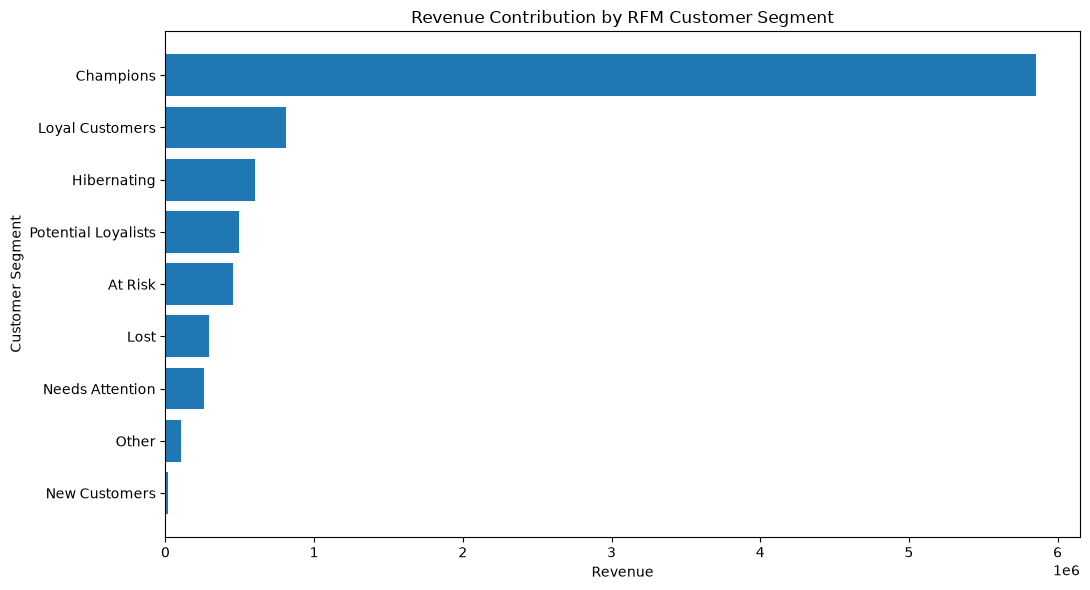

In [44]:
# Visualización: revenue por segmento RFM
# Usamos matplotlib para evitar dependencias adicionales

plot_data = segment_performance.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_data["Segment"],
    plot_data["Revenue"]
)

plt.title("Revenue Contribution by RFM Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

### Segmentación de clientes RFM — Hallazgos clave

El análisis RFM revela una estructura de valor del cliente altamente concentrada:

- Los **Campeones** representan el 25,84 % de los clientes, pero generan el **65,91 % de los ingresos totales**, lo que los convierte en el segmento de clientes más importante desde el punto de vista económico.
- Los **Clientes leales** aportan un **9,09 % adicional de los ingresos**.
- En conjunto, los Campeones y los Clientes leales generan aproximadamente el **75 % de los ingresos totales**.
- Los clientes **En riesgo** todavía aportan el **5,10 % de los ingresos** y muestran un valor histórico relativamente alto, lo que los convierte en un grupo importante para posibles estrategias de reactivación.
- Los clientes en **Hibernación** representan el 20,40 % de la base de clientes, pero generan solo el 6,79 % de los ingresos y tienen una recencia promedio de aproximadamente 191 días.
- Los **Nuevos clientes** representan actualmente menos del 1 % de la base de clientes y contribuyen solo con el 0,18 % de los ingresos totales.

### Interpretación empresarial

El valor del cliente está fuertemente concentrado en una proporción relativamente pequeña de la base de clientes. Esto sugiere que la retención de clientes es particularmente importante para el negocio.

La elevada contribución de los Campeones indica que proteger las relaciones con clientes de alto valor debería ser una prioridad. Al mismo tiempo, los clientes En riesgo representan una oportunidad potencial de reactivación, ya que han demostrado un valor histórico significativo, aunque no han realizado compras recientemente.

Los **Clientes potencialmente leales** representan otra oportunidad de crecimiento relevante, dado que su comportamiento de compra reciente sugiere el potencial de convertirse en clientes recurrentes de mayor valor.

### Implicación analítica

La segmentación RFM proporciona un marco conductual para priorizar grupos de clientes basándose en la recencia, la frecuencia y la contribución monetaria. Estos segmentos deben interpretarse como perfiles analíticos de clientes, más que como categorías comerciales definitivas.

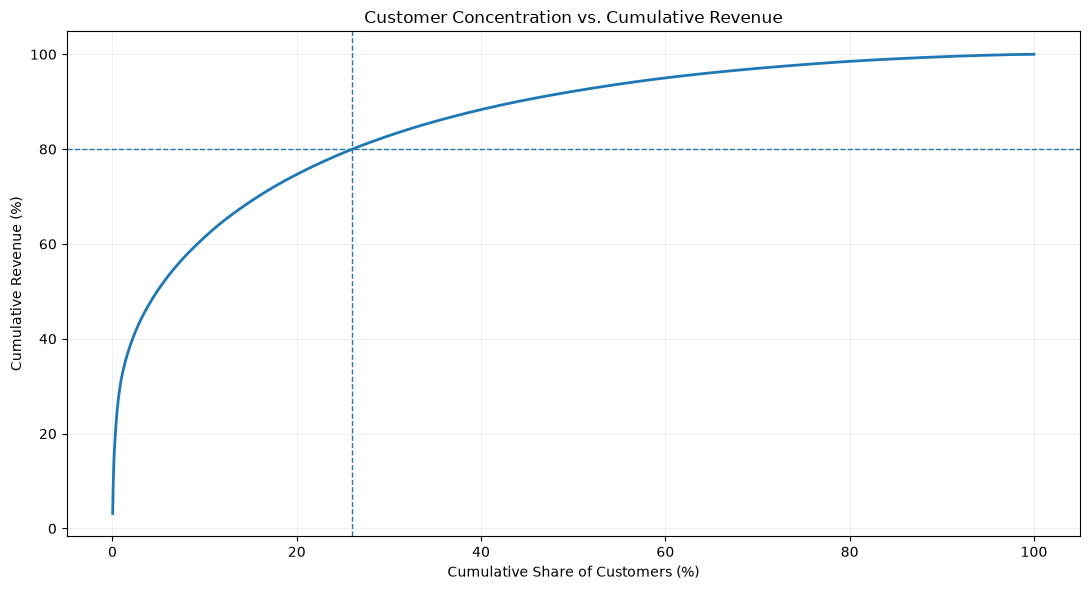

In [45]:
# Visualización: concentración acumulada del revenue por cliente

pareto_data = customer_value_ranking.copy()

pareto_data["Customer_Rank_%"] = (
    (pareto_data.index + 1) / len(pareto_data) * 100
)

plt.figure(figsize=(11, 6))

plt.plot(
    pareto_data["Customer_Rank_%"],
    pareto_data["Cumulative_Revenue_%"],
    linewidth=2
)

# Referencias del principio 80%
plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=customer_share_to_80,
    linestyle="--",
    linewidth=1
)

plt.title("Customer Concentration vs. Cumulative Revenue")
plt.xlabel("Cumulative Share of Customers (%)")
plt.ylabel("Cumulative Revenue (%)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

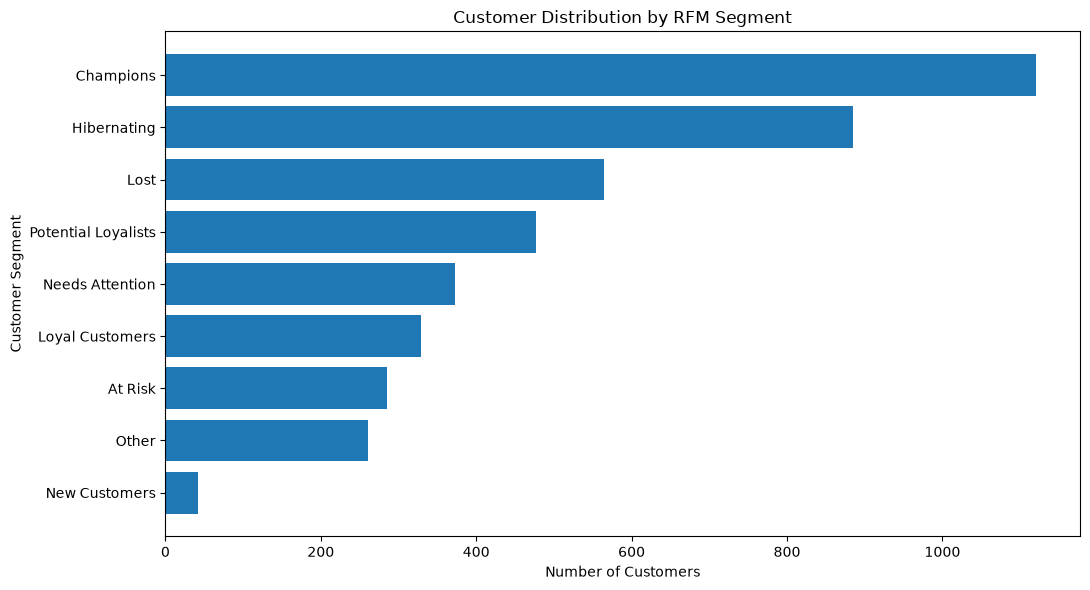

In [46]:
# Visualización: distribución de clientes por segmento RFM

segment_plot = segment_performance.sort_values(
    "Customers",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    segment_plot["Segment"],
    segment_plot["Customers"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

### Análisis de clientes — Conclusión

El análisis de clientes revela que la generación de ingresos es muy desigual en toda la base de clientes.

Aunque los clientes recurrentes representan el 65,58 % de los clientes identificados, generan el 93,09 % de los ingresos totales atribuidos a los clientes. La segmentación RFM muestra además que **los «Campeones» por sí solos aportan el 65,91 % de los ingresos**, mientras que los «Campeones» y los «Clientes leales» suman conjuntamente alrededor del 75 %.

El análisis de concentración de clientes también indica que aproximadamente el **26,05 % de los clientes genera el 80 % de los ingresos totales**, lo que confirma que una proporción relativamente reducida de la base de clientes impulsa la mayor parte del valor económico.

Desde una perspectiva empresarial, surgen tres prioridades:

1. **Proteger a los clientes de alto valor**: los «Campeones» y los «Clientes leales» constituyen la base económica fundamental del negocio.
2. **Reactivar a clientes inactivos valiosos**: los clientes «En riesgo» han demostrado un valor histórico significativo y representan una oportunidad potencial de recuperación.
3. **Desarrollar relaciones emergentes**: los «Clientes leales potenciales» representan una oportunidad para aumentar la recurrencia de compra y migrar a los clientes hacia segmentos de mayor valor.

En conjunto, el análisis sugiere que las estrategias de retención, reactivación y desarrollo de clientes pueden tener un mayor impacto económico que tratar a todos los clientes de manera uniforme.

# 7. Resumen Ejecutivo

Este análisis exploratorio permitió identificar varios patrones importantes en el conjunto de datos de Online Retail relacionados con el desempeño de las ventas, el comportamiento de los clientes y la concentración de los ingresos.

## Principales Hallazgos

### Estructura de los Ingresos

Los ingresos no se distribuyen de manera uniforme entre las transacciones, los productos y los clientes. Una proporción relativamente pequeña del negocio genera una parte considerable del valor económico total.

### Retención de Clientes

Los clientes recurrentes representan el **65.58% de los clientes identificados**, pero generan el **93.09% de los ingresos atribuibles a clientes**, lo que indica que la recurrencia de compra es uno de los principales impulsores del desempeño del negocio.

### Concentración de Clientes

Aproximadamente el **26.05% de los clientes genera el 80% de los ingresos totales**, lo que demuestra una fuerte concentración del valor económico en una parte relativamente pequeña de la base de clientes.

### Segmentación RFM

El análisis RFM identificó a los **Champions** como el segmento de mayor importancia económica. Representan el **25.84% de los clientes** y generan el **65.91% de los ingresos totales**.

En conjunto, los segmentos **Champions** y **Loyal Customers** generan aproximadamente el **75% de los ingresos**.

### Oportunidades de Crecimiento

Los **Potential Loyalists** representan una oportunidad para desarrollar relaciones de compra más recurrentes, mientras que los clientes **At Risk** representan una oportunidad potencial de reactivación debido al valor que han generado históricamente.

## Recomendaciones de Negocio

A partir de los resultados del análisis exploratorio, el negocio debería priorizar:

1. Retener y proteger a los clientes de alto valor.
2. Desarrollar a los Potential Loyalists para convertirlos en clientes recurrentes.
3. Reactivar a los clientes At Risk que anteriormente generaron valor para el negocio.
4. Monitorear la concentración de clientes e ingresos como un posible riesgo para el negocio.
5. Utilizar la segmentación de clientes para desarrollar estrategias diferenciadas en lugar de tratar a toda la base de clientes de la misma manera.

## Conclusión

El análisis indica que el desempeño del negocio depende en gran medida de la retención de clientes y de un comportamiento de compra altamente concentrado.

En lugar de enfocarse exclusivamente en el volumen de transacciones o en la adquisición de nuevos clientes, las futuras estrategias comerciales deberían considerar el comportamiento del cliente a lo largo del tiempo, la retención, la reactivación y el desarrollo de relaciones con clientes de alto potencial.

Estos hallazgos proporcionan una base analítica para el posterior desarrollo de dashboards y recomendaciones de negocio.